# Climate Downscaling using CNN (ERA5 → PRISM)

This notebook demonstrates a deep learning approach for climate downscaling.

ERA5 provides low-resolution atmospheric data, while PRISM provides higher-resolution ground truth data.

A Convolutional Neural Network (CNN) is used to learn how to enhance spatial resolution.

Goal:
Learn a mapping from coarse climate data to fine-scale predictions.


## Import Required Libraries

This section loads all required libraries for deep learning, data handling, and visualization.


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import sys
import os

sys.path.append(os.path.abspath(".."))

## Load ERA5 and PRISM Dataset

The dataset provides paired samples:
- ERA5: low-resolution input
- PRISM: high-resolution target

Each sample represents a spatial grid of temperature values.

In [20]:
from datasets.prism_dataset import ERA5_PRISM_Dataset

dataset = ERA5_PRISM_Dataset(
    "../data_raw/era5_georgia_temp.nc",
    "../data_raw/prism/prism_tmean_2023.nc"
)

x, y = dataset[0]

print("Input shape:", x.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([1, 21, 21])
Target shape: torch.Size([1, 21, 21])


## Prepare Input for Model

The model expects input in the format:
(batch_size, channels, height, width)

We add a batch dimension to match this format.

In [21]:
x = x.unsqueeze(0)

print("Model input shape:", x.shape)

Model input shape: torch.Size([1, 1, 21, 21])


## Load Trained CNN Model

A trained CNN model is loaded from disk.

This model has learned to map low-resolution ERA5 inputs to higher-resolution outputs.


In [22]:
from models.cnn_downscaler import CNNDownscaler

model = CNNDownscaler()
model.load_state_dict(torch.load("../model.pth"))
model.eval()

CNNDownscaler(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

## Generate Prediction

The model processes the input and produces a predicted high-resolution output.

Interpolation is applied to match the spatial resolution of the ground truth.


In [23]:
with torch.no_grad():
    pred = model(x)
    pred = F.interpolate(pred, size=y.shape[-2:], mode="bilinear", align_corners=False)

## Convert Tensors to NumPy

Convert model outputs and inputs into NumPy format for visualization.

In [24]:
low_res = x.squeeze().numpy()
prediction = pred.squeeze().numpy()
ground_truth = y.squeeze().numpy()

## Visualization: Input vs Prediction vs Ground Truth

This section compares:
- ERA5 Input (low resolution)
- Model Prediction
- PRISM Ground Truth

This helps evaluate how well the model improves spatial detail.


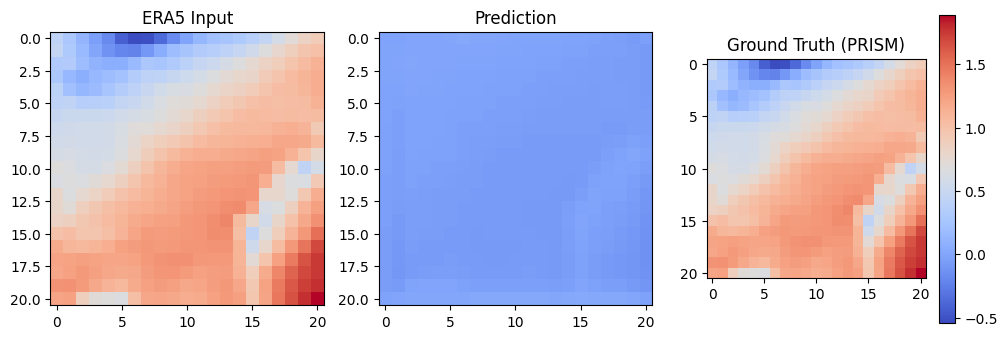

In [25]:
vmin = min(low_res.min(), prediction.min(), ground_truth.min())
vmax = max(low_res.max(), prediction.max(), ground_truth.max())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("ERA5 Input")
plt.imshow(low_res, cmap="coolwarm", vmin=vmin, vmax=vmax)

plt.subplot(1,3,2)
plt.title("Prediction")
plt.imshow(prediction, cmap="coolwarm", vmin=vmin, vmax=vmax)

plt.subplot(1,3,3)
plt.title("Ground Truth (PRISM)")
plt.imshow(ground_truth, cmap="coolwarm", vmin=vmin, vmax=vmax)

plt.colorbar()
plt.show()

## Model Evaluation

We compute RMSE between prediction and ground truth to quantify performance.

In [26]:
rmse = np.sqrt(np.mean((prediction - ground_truth) ** 2))
print("RMSE:", rmse)

RMSE: 1.0342295


## Conclusion

The CNN model captures general spatial patterns from ERA5 input data.

While the prediction follows the overall structure of the PRISM ground truth, some fine-scale details are not fully reconstructed.

This demonstrates that CNN-based downscaling is effective but can be improved.

Future Work:
- Use UNet architecture for better spatial detail
- Train on larger datasets
- Incorporate temporal information## Model Evaluation

We compute RMSE between prediction and ground truth to quantify performance.